# Sentence Embedding Models & Semantic Similarity

When you turn a sentence into a vector (e.g., with BERT, Sentence‑BERT, Universal Sentence Encoder, etc.) the vector lives in a high‑dimensional space where directions capture meaning and magnitudes are mostly an artefact of how the model was trained.

Cosine similarity answers the question:
“How aligned are two direction vectors?”

cosine‑sim(a,b)=cosθ= a⋅b / ∥a∥∥b∥
​
 


## Imports & Configs

In [4]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

model_name = "mixedbread-ai/mxbai-embed-large-v1" # from config.json: "hidden_size": 1024
model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1")

In [2]:
# device setup
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: mps


## Turn sentences into vectors (embeddings) using Sentence Transformer models (BERT-style)

In [ ]:
query = "A man is eating a piece of bread"
docs = [
    "A man is eating food.",
    "A man is eating pasta.",
    "The girl is carrying a baby.",
    "A man is riding a horse.",
]

In [96]:
# maps any English sentence to a Hidden Size (1024‑dimensional, in case of current "mxbai-embed-large-v1") float vector.
query_embedding = model.encode(query, prompt_name="query", device=DEVICE)
docs_embeddings = model.encode(docs, device=DEVICE)

In [97]:
print(f'The shape of the embedding for the query: {query_embedding.shape}')  # the model's hidden size is 1024
print(f'The shape of the embedding for the docs: {docs_embeddings.shape}')

The shape of the embedding for the query: (1024,)
The shape of the embedding for the docs: (4, 1024)


## Calculate cosine similarity between embedded query and docs vectors

In [ ]:
# not normalized embedding input
similarities = cos_sim(query_embedding, docs_embeddings)
print('similarities:', similarities)

similarities: tensor([[0.7920, 0.6369, 0.1651, 0.3621]])


The argument `normalize_embeddings=True` already divides each vector by its Euclidean norm (L2), so the vectors lie on the unit hypersphere (‖v‖ = 1). 
In that case cosine similarity equals the dot‑product (because the denominator in the cosine-sim(a,b) formula equals 1).

In [107]:
docs_embeddings_norm = model.encode(docs, normalize_embeddings=True, device=DEVICE)  # L2‑normalise now
query_embedding_norm = model.encode(query, normalize_embeddings=True, device=DEVICE) # L2‑normalise now

In [117]:
print(f'Euclidean norm (L2) of normalized embeddings: {np.linalg.norm(query_embedding_norm)}')
print(f'Euclidean norm (L2) of not-normalized embeddings: {np.linalg.norm(query_embedding)}')

Euclidean norm (L2) of normalized embeddings: 1.0
Euclidean norm (L2) of not-normalized embeddings: 17.375728607177734


__Manually compute cosine similarity__

In [ ]:
def cosine_sim(a, b):
    '''Compute cosine similarity between two vectors a and b, 
    including calculate vector norm (default Euclidean norm) as in the formula denominator.'''
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Manual calculation (normalized input)
for doc_embed in docs_embeddings_norm:
    print("Manual calculation with cosine_sim (normalized input):", cosine_sim(query_embedding_norm, doc_embed))

# Using Sentence‑Transformers utility (normalized input)
print("SentenceTransformer utility (normalized input):", cos_sim(query_embedding_norm, docs_embeddings_norm))

# Manual calculation with only dot‑product, normalized input (normalize_embeddings=True)
for doc_embed in docs_embeddings_norm:
    print("Manual calculation with dot‑product (normalized input):", np.dot(query_embedding_norm, doc_embed))

Manual calculation with cosine_sim (normalized input): 0.8183207
Manual calculation with cosine_sim (normalized input): 0.65497375
Manual calculation with cosine_sim (normalized input): 0.13623461
Manual calculation with cosine_sim (normalized input): 0.35965085
SentenceTransformer utility (normalized input): tensor([[0.8183, 0.6550, 0.1362, 0.3597]])
Manual calculation with dot‑product (normalized input): 0.81832063
Manual calculation with dot‑product (normalized input): 0.65497375
Manual calculation with dot‑product (normalized input): 0.13623461
Manual calculation with dot‑product (normalized input): 0.35965085


## Another full example
a customer‑support chatbot that needs to find the most relevant FAQ entry for a user’s query.

In [126]:
faq = [
    "How do I reset my password?",
    "Why was my payment declined?",
    "What to do if you forget your username?",
    "Troubleshooting login issues",
    "Changing your email address"
]
query = "I can't log into my account."

query_embedding = model.encode([query], normalize_embeddings=True)
faq_embedding = model.encode(faq, normalize_embeddings=True)

sims = cos_sim(query_embedding, faq_embedding)
best_idx = int(sims.argmax())
print(f"User query: {query}")
print("Best match:", faq[best_idx])
print("Score:", sims[0, best_idx].item())

User query: I can't log into my account.
Best match: How do I reset my password?
Score: 0.7508924007415771


## Visualizing a latent semantic space with t‑SNE / UMAP

Need to distinguish between 2 related terms: _Literal semantic language space_ vs _Latent semantic space_.

In [127]:
faq_questions = [
    "How can I reset my password?",
    "I forgot my username, what should I do?",
    "Why was my credit card declined?",
    "Can I change my shipping address after ordering?",
    "What is the refund policy for returned items?",
    "My order arrived damaged, how can I get a replacement?",
    "Do you offer international shipping?",
    "How long does standard delivery take?",
    "I want to cancel my subscription. How do I proceed?",
    "Is there a discount for bulk purchases?"
]

faq_embedding = model.encode(faq_questions, normalize_embeddings=True)
print(f"Shape of raw embeddings: {faq_embedding.shape}")

Shape of raw embeddings: (10, 1024)


In [168]:
query = "I can't log into my account."
q_embed = model.encode([query], normalize_embeddings=True)

In [ ]:
# Cosine similarity between user query to FAQ list
similarities = cos_sim(q_embed, faq_embedding)
print(f'Cosine similarities: {similarities}')
print(f'FAQ Best Match: {faq[np.argmax(similarities)]}')

# for doc_embed in faq_embedding:
#     print("Manual calculation with dot‑product (normalized input):", np.dot(q_embed, doc_embed))

Cosine similarities: tensor([[0.7550, 0.6570, 0.4769, 0.3328, 0.3810, 0.4441, 0.3086, 0.3481, 0.4624,
         0.3360]])
FAQ Best Match: How do I reset my password?


In [165]:
# --------------------------------------------------------------
# 4️⃣ Optional: run a quick K‑means to obtain "pseudo‑clusters"
# --------------------------------------------------------------
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_ids = kmeans.fit_predict(faq_embedding)

__The intuition behind perplexity in t‑SNE__

t‑SNE builds a probability distribution over pairs of points that reflects how “close” they are in the original high‑dimensional space.

Perplexity ≈ effective number of neighbours t‑SNE tries to keep locally consistent with.
If you set perplexity = 30, the algorithm will behave as if each point “sees” roughly 30 nearest neighbours when shaping the low‑dimensional map.
Why the rule perplexity < n_samples?
The conditional probability for a given point must sum to 1 over all other points.

If you ask t‑SNE to treat, say, 30 neighbours as its effective neighbourhood but you only have 10 data points, the math breaks down: there simply aren’t enough points to allocate that much probability mass. The implementation therefore throws an error:

ValueError: perplexity must be less than number of samples
Practical guidelines
Dataset size	Reasonable perplexity range
< 30 points	5 – (n_samples‑1) (often as low as 2–3 works)
30 – 500 points	5 – 50 (default 30 is a good start)

**The perplexity**:
is related to the number of nearest neighbors that is used in other manifold learning algorithms. Larger datasets usually require a larger perplexity. Consider selecting a value between 5 and 50. Different values can result in significantly different results. The perplexity must be less than the number of samples.

In [ ]:
# --------------------------------------------------------------
# 5️⃣ Dimensionality reduction with t‑SNE
# --------------------------------------------------------------

# Choose a *valid* perplexity
n_samples = faq_embedding.shape[0]
max_perplexity = max(1, n_samples - 1)  # t‑SNE rule: < n_samples
# Heuristic: pick something in the typical 5–50 range but never larger than max.
perplexity = min(30, max_perplexity)  # can change this default value
print(f"Using perplexity = {perplexity} (max allowed = {max_perplexity})")

tsne = TSNE(
    n_components=2, # dimension of the embedded space.
    metric="cosine",  # because embeddings are on a hypersphere
    perplexity=perplexity,
    learning_rate='auto',
    init="random",
    random_state=42,
    verbose=0,
)
embed_tsne = tsne.fit_transform(faq_embedding)

# For pure‑scikit‑learn TSNE you have to recompute the embedding jointly with the query because it has no .transform method.
# With UMAP you can call .transform. method directly on umap_reducer object

Using perplexity = 9 (max allowed = 9)


**`n_neighbors` argument in UMAP:**

This parameter controls how UMAP balances local versus global structure in the data. It does this by constraining the size of the local neighborhood UMAP will look at when attempting to learn the manifold structure of the data. This means that low values of n_neighbors will force UMAP to concentrate on very local structure (potentially to the detriment of the big picture), while large values will push UMAP to look at larger neighborhoods of each point when estimating the manifold structure of the data, losing fine detail structure for the sake of getting the broader of the data.

In [ ]:
# --------------------------------------------------------------
# 6️⃣ Dimensionality reduction with UMAP (for comparison)
# --------------------------------------------------------------
umap_reducer = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=perplexity,  # analogous to t-SNE perplexity
    min_dist=0.1,
    random_state=42
)
embed_umap = umap_reducer.fit_transform(faq_embedding)
# Project with the *already fitted* reducers:
q_embed_umap = umap_reducer.transform([q_embed])

/opt/homebrew/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [143]:
print(f'Shape of the t-SNE embedding (n_samples, n_reduced_dims): {emb_tsne.shape}')

Shape of the t-SNE embedding (n_samples, n_reduced_dims): (10, 2)


### 2D-Scatter Plot

In [24]:
# --------------------------------------------------------------
# 7️⃣ Helper to plot a scatter with annotations
# --------------------------------------------------------------
def plot_2d(ax, points, sentences: list, title: str, n_clusters: int=0):
    '''
    Plot 2D scatter plot (for PCA, t-SNE or UMAP dimensionality reduction method) with optional clusters coloring, and with the original labels provided.
    '''

    if n_clusters == 0:  # no clustering was perfomed
            ax.scatter(
            points[:, 0], points[:, 1],
            s=120, color="darkblue",
            alpha=0.8, edgecolor="k",
        )
    else:  # k-means or other type of clustering
        palette = sns.color_palette("deep", n_clusters)
        for i in range(n_clusters):
            idx = np.where(cluster_ids == i)[0]
            ax.scatter(
                points[idx, 0], points[idx, 1],
                s=120, color=palette[i],
                label=f"Cluster {i+1}",
                alpha=0.8,  edgecolor="k",
            )
    # annotate each point with the FAQ text (truncated after X-characters)
    for i, txt in enumerate(sentences):
        ax.text(
            points[i, 0] + 0.02,
            points[i, 1] + 0.02,
            txt[:50],  # truncate to 50 characters
            fontsize=9,
            ha="left",
            va="bottom",
        )
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


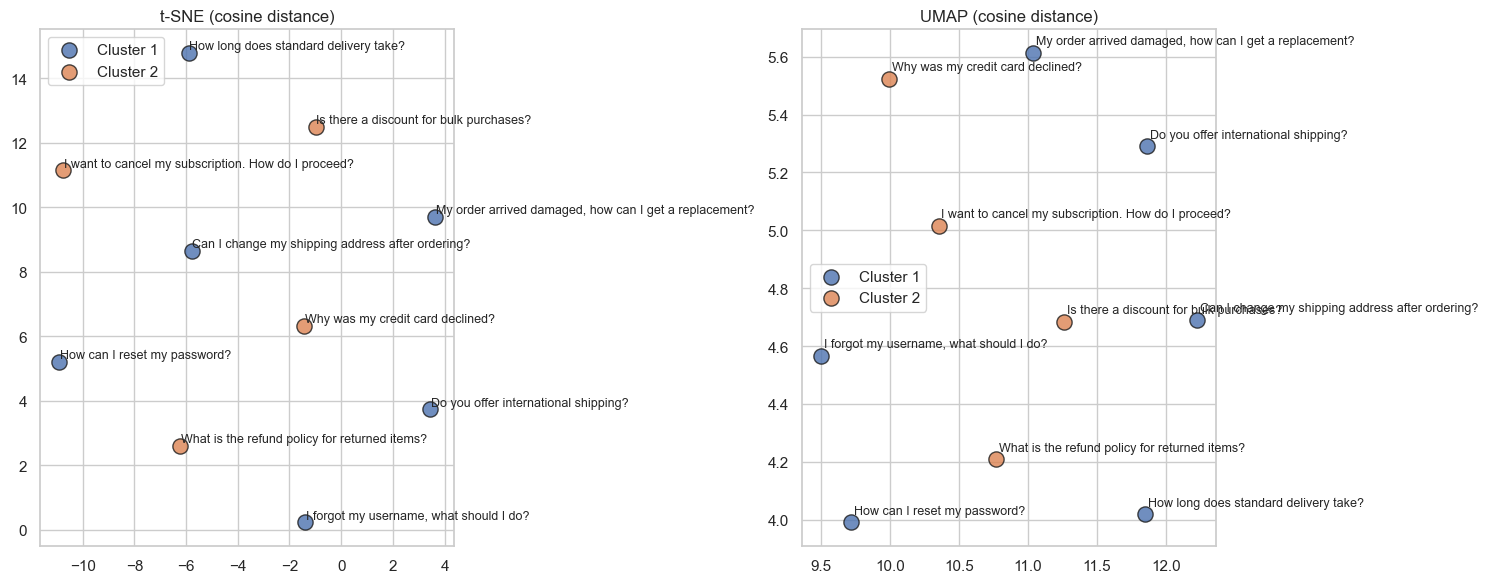

In [167]:
# --------------------------------------------------------------
# 8️⃣ Plot both reductions side‑by‑side
# --------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

plot_2d(axs[0], embed_tsne, "t-SNE (cosine distance)")
plot_2d(axs[1], embed_umap, "UMAP (cosine distance)")
plt.tight_layout()
plt.show()

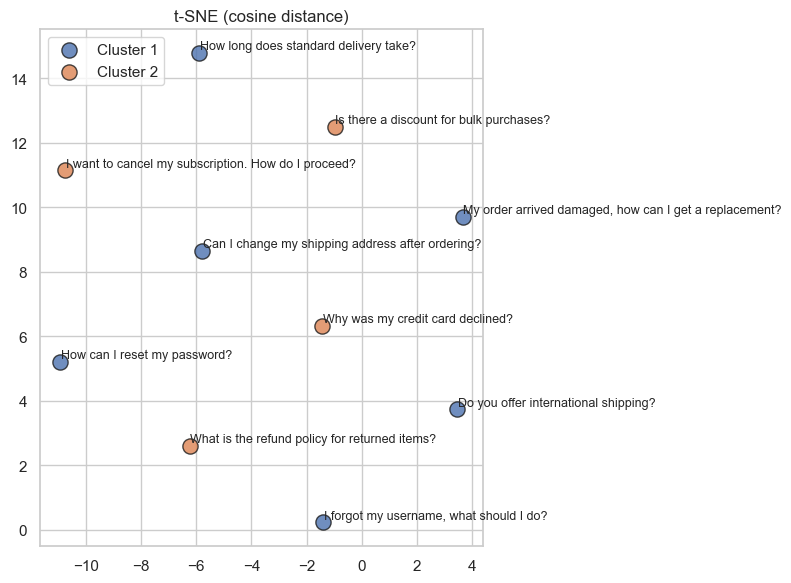

In [174]:
# plot a single 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6)) # one Axes object, not an array
plot_2d(ax, embed_tsne, "t-SNE (cosine distance)")
plt.tight_layout()
plt.show()

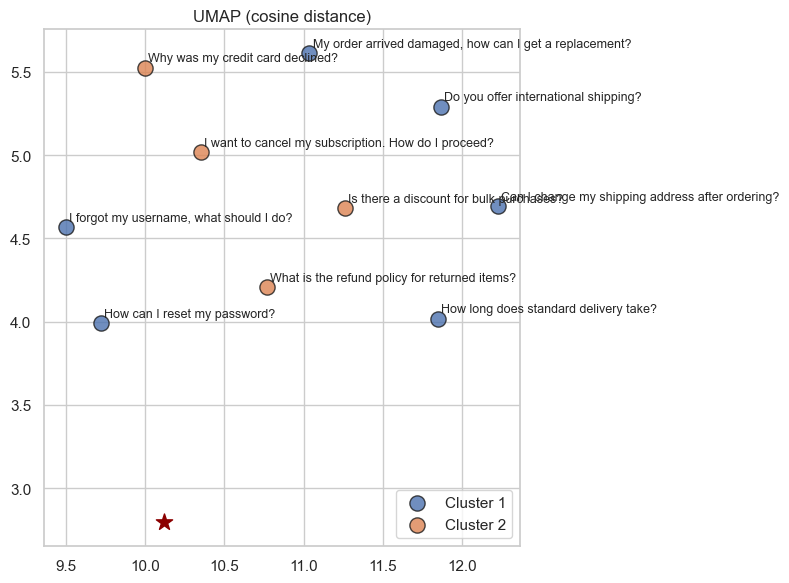

In [178]:
# plot a single 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6)) # one Axes object, not an array
plot_2d(ax, embed_umap, "UMAP (cosine distance)")
# Overlay the query embedding point, make it shape a str
plt.scatter(q_embed_umap[:, 0], q_embed_umap[:, 1], color='darkred', marker='*', s=150)
plt.tight_layout()
plt.show()

## Another my custom example


In [ ]:
corpus = [
    "The cat sits on the mat.",
    "A dog is playing in the garden.",
    "A lion is running in the forest after a deer",
    "I love eating pizza with extra cheese.",
    "Pasta is an Italian very popular dish",
    "Humus is a delicious spread made from chickpeas.",
    "Artificial intelligence and machine learning are transforming industry.",
    "Data Science is a field that uses scientific methods, processes, algorithms and systems to extract knowledge and insights.",
    "I am working in the field of Bioinformatics, which combines biology, computer science, and information technology."
]

query = "I love tasting different foods, especially Italian ones"

corpus_embedding = model.encode(corpus, normalize_embeddings=True)
query_embedding = model.encode(query, normalize_embeddings=True)

print(f"Shape of corpus embeddings: {corpus_embedding.shape}")
print(f"Shape of query embeddings: {query_embedding.shape}")

Shape of corpus embeddings: (9, 1024)
Shape of query embeddings: (1024,)


In [30]:
# Cosine similarity between user query to FAQ list
similarities = cos_sim(query_embedding, corpus_embedding)
print(f'Cosine similarities: {similarities}')
print(f'Corpus Best Match: {corpus[np.argmax(similarities)]}')

Cosine similarities: tensor([[0.2574, 0.3180, 0.2100, 0.7179, 0.6799, 0.5060, 0.2981, 0.2967, 0.4139]])
Corpus Best Match: I love eating pizza with extra cheese.


In [31]:
# Choose a *valid* perplexity
n_samples = corpus_embedding.shape[0]
max_perplexity = max(1, n_samples - 1)  # t‑SNE rule: < n_samples
# Heuristic: pick something in the typical 5–50 range but never larger than max.
perplexity = min(30, max_perplexity)  # can change this default value
print(f"Using perplexity = {perplexity} (max allowed = {max_perplexity})")

tsne = TSNE(
    n_components=2, # dimension of the embedded space.
    metric="cosine",  # because embeddings are on a hypersphere
    perplexity=perplexity,
    learning_rate='auto',
    init="random",
    random_state=42,
    verbose=0,
)
corpus_embedding_tsne = tsne.fit_transform(corpus_embedding)

Using perplexity = 8 (max allowed = 8)


In [ ]:
umap_reducer = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=perplexity,  # analogous to t-SNE perplexity
    min_dist=0.1,
    random_state=42
)
corpus_embedding_umap = umap_reducer.fit_transform(corpus_embedding)
# Project with the *already fitted* reducers:
query_embedding_umap = umap_reducer.transform([query_embedding])

In [20]:
# length of each sentence:
[len(sentence) for sentence in corpus]

[24, 31, 44, 38, 37, 48, 71, 122, 114]

In [37]:
# k-means clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_ids = kmeans.fit_predict(corpus_embedding)

/var/folders/y_/2xtp4jn551g4kc50l69n92dr0000gn/T/ipykernel_98242/3990368606.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


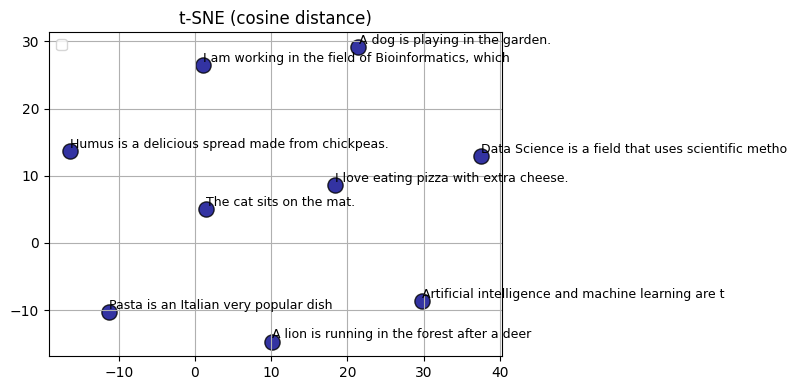

In [46]:
# Plot the t-SNE without clustering
fig, ax = plt.subplots(figsize=(8, 4)) # one Axes object, not an array
plot_2d(ax, corpus_embedding_tsne, corpus, "t-SNE (cosine distance)", 0)
plt.tight_layout()
plt.show()

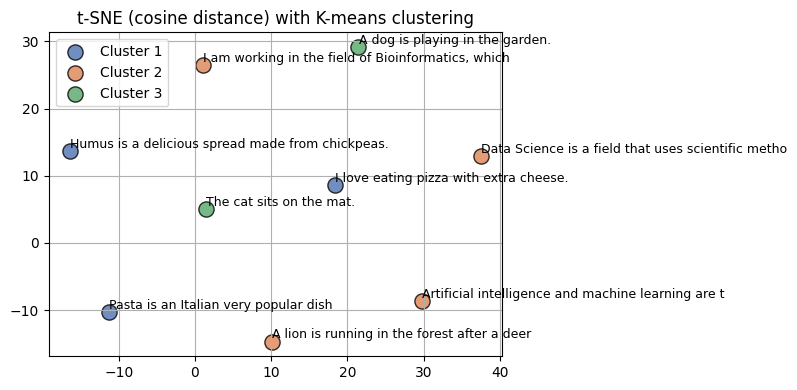

In [50]:
fig, ax = plt.subplots(figsize=(8, 4)) # one Axes object, not an array
plot_2d(ax, corpus_embedding_tsne, corpus, "t-SNE (cosine distance) with K-means clustering", n_clusters)
plt.tight_layout()
plt.show()

/var/folders/y_/2xtp4jn551g4kc50l69n92dr0000gn/T/ipykernel_98242/3990368606.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


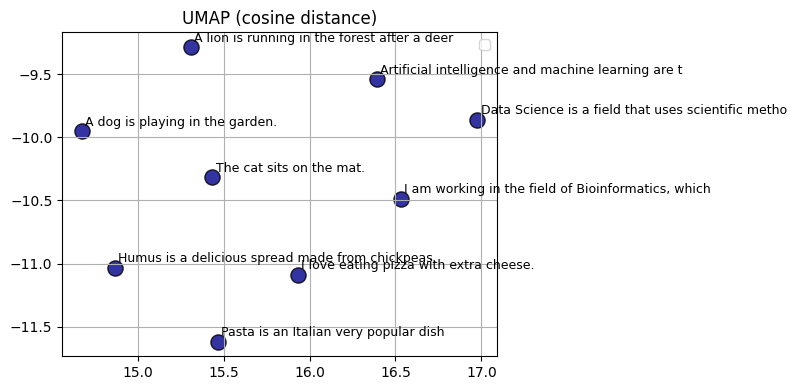

In [47]:
# Plot the UMAP without clustering
fig, ax = plt.subplots(figsize=(8, 4)) # one Axes object, not an array
plot_2d(ax, corpus_embedding_umap, corpus, "UMAP (cosine distance)", 0)
plt.tight_layout()
plt.show()

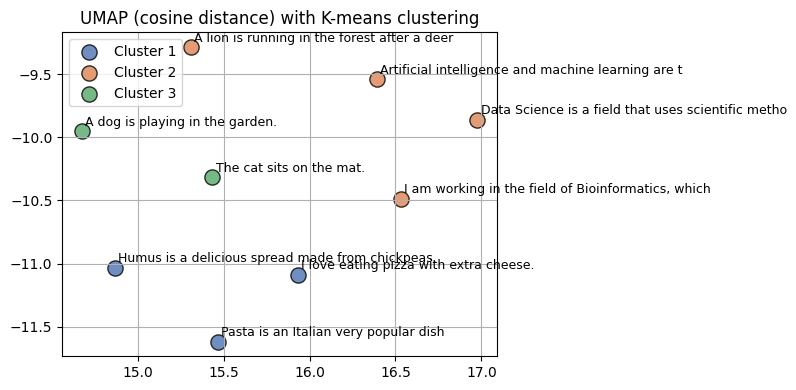

In [52]:
# Plot the UMAP with clustering
fig, ax = plt.subplots(figsize=(8, 4)) # one Axes object, not an array
plot_2d(ax, corpus_embedding_umap, corpus, "UMAP (cosine distance) with K-means clustering", n_clusters)
plt.tight_layout()
plt.show()

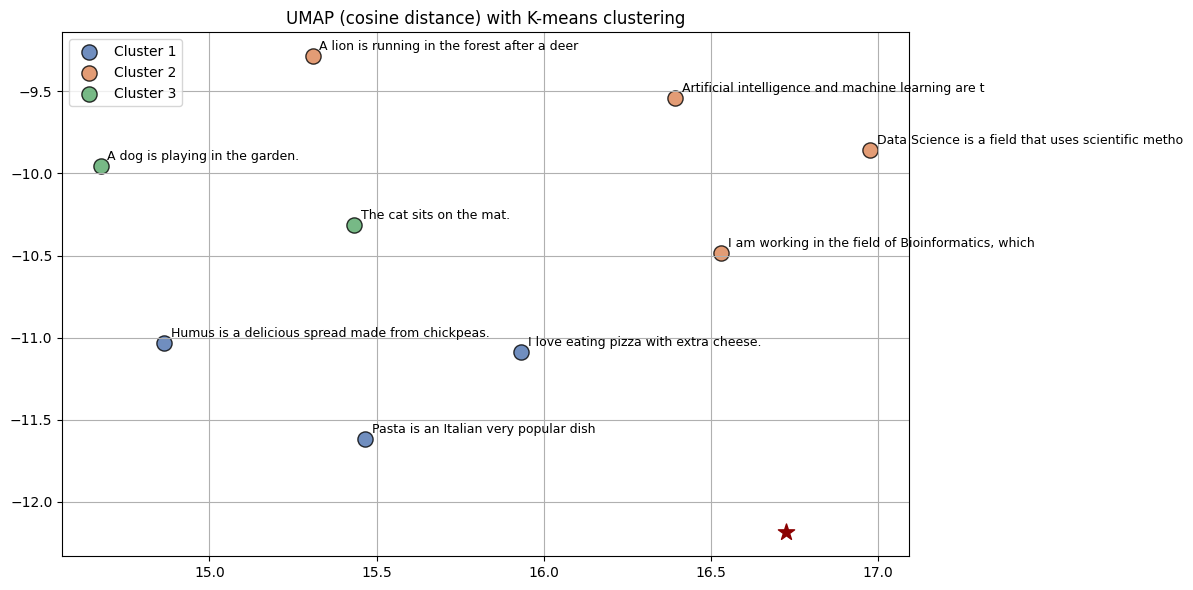

In [53]:
# Plot the UMAP with clustering and with the query sentence
fig, ax = plt.subplots(figsize=(12, 6)) # one Axes object, not an array
plot_2d(ax, corpus_embedding_umap, corpus, "UMAP (cosine distance) with K-means clustering", n_clusters)
# Overlay the query embedding point, make it shape a str
plt.scatter(query_embedding_umap[:, 0], query_embedding_umap[:, 1], color='darkred', marker='*', s=150)
plt.tight_layout()
plt.show()